# Experiment A+: Gating Stress Test with Augmented Training

**Goal:** Train a transformer on DMD data **with synthetic occlusion augmentation**, then stress-test the gating mechanism under synthetic occlusion. Compare against Experiment A (clean training) to show that occlusion-aware training further strengthens the gating mechanism.

**Augmentation strategy (training only):**
- For each subject, frame indices are divided per-subject into four buckets:
  - 60 % clean (no overlay)
  - ~13 % eye_only (sunglasses band, one random opacity)
  - ~13 % mouth_only (mask rectangle, one random opacity)
  - ~14 % both (eye + mouth, one random opacity)
- Augmented features **and** occlusion probabilities are extracted from the synthetically occluded frame.
- Test frames are always clean during extraction; they are occluded systematically in the stress-test phase (identical to Experiment A).

**Pipeline:**
1. Extract features from DMD frames with per-subject augmentation + stratified train/val split
2. Train the selected transformer architecture from scratch
3. Stress test: apply synthetic occlusion to test frames, compare gating ON vs OFF

In [32]:
import os
# Avoid ONNX Runtime thread-affinity failures on HPC (pthread_setaffinity_np)
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OMP_WAIT_POLICY'] = 'PASSIVE'

import sys, time, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports ready.')

Device: cpu
Imports ready.


In [33]:
# ===========================  CONFIG  ===========================
#  'enhanced'  ->  EnhancedOcclusionAwareTransformer
#  'level2'    ->  Level2DynamicOcclusionAwareTransformer

MODEL_TYPE = 'enhanced'

# Frame sampling: set to 100 for CPU quick test, None for full GPU run
NUM_SAMPLES_PER_VIDEO = 100 if device.type == 'cpu' else None

NUM_EPOCHS      = 20
LEARNING_RATE   = 3e-5
BATCH_SIZE      = 32
HIDDEN_DIM      = 128
NUM_HEADS       = 4
NUM_LAYERS      = 3
MAX_PER_SUBJECT = 30 if device.type == 'cpu' else None  # stress-test sampling

# Augmentation: fraction of each subject's training frames kept clean
AUG_CLEAN_FRACTION = 0.60   # 60 % clean | ~13 % eye | ~13 % mouth | ~14 % both

print(f'Model:              {MODEL_TYPE}')
print(f'Samples/video:      {NUM_SAMPLES_PER_VIDEO or "ALL"}')
print(f'Stress-test/subj:   {MAX_PER_SUBJECT or "ALL"}')
print(f'Epochs:             {NUM_EPOCHS}')
print(f'Aug clean fraction: {AUG_CLEAN_FRACTION}')

Model:              enhanced
Samples/video:      100
Stress-test/subj:   30
Epochs:             20
Aug clean fraction: 0.6


In [34]:
import importlib
import occlusion_audit_utils, dofg_pipeline, synthetic_occlusion_utils
importlib.reload(occlusion_audit_utils)
importlib.reload(dofg_pipeline)
importlib.reload(synthetic_occlusion_utils)

from occlusion_audit_utils import (
    CONFIG, load_csv_video_data, FaceDetector,
    ResNet34OcclusionModel, sample_frames_for_audit,
)
from dofg_pipeline import (
    ResNet34FeatureExtractor,
    split_video_ids,
    extract_features_with_augmentation,
)
from synthetic_occlusion_utils import apply_synthetic_occlusion, OPACITY_LEVELS

if MODEL_TYPE == 'enhanced':
    from dofg_pipeline import EnhancedOcclusionAwareTransformer as TransformerCls
elif MODEL_TYPE == 'level2':
    import level2_dynamic_transformer
    importlib.reload(level2_dynamic_transformer)
    from level2_dynamic_transformer import Level2DynamicOcclusionAwareTransformer as TransformerCls
else:
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')

print(f'Transformer: {TransformerCls.__name__}')

Transformer: EnhancedOcclusionAwareTransformer


## 1. Load Data & Models

In [35]:
csv_data = load_csv_video_data(CONFIG['CSV_DATASET_PATH'])

face_detector = FaceDetector(
    shape_model_path=CONFIG['DLIB_MODEL_PATH'],
    det_size=(640, 640), det_thresh=0.35,
)
occ_model = ResNet34OcclusionModel(
    CONFIG['RESNET34_OCCLUSION_MODEL_PATH'], device=str(device),
)
feat_extractor = ResNet34FeatureExtractor(
    CONFIG['RESNET34_MODEL_PATH'], device=str(device),
)
print('All models loaded.')

Loading CSV video data from: Data
  Sub1_sub1_video: 4256 frames (filtered 1224)
  Sub10_sub10_video: 4440 frames (filtered 1615)
  Sub11_sub11_video: 4049 frames (filtered 1328)
  Sub12_sub12_video: 4562 frames (filtered 1014)
  Sub13_sub13_video: 4246 frames (filtered 1134)
  Sub14_sub14_video: 4585 frames (filtered 929)
  Sub15_sub15_video: 3957 frames (filtered 1337)
  Sub2_sub2_video: 4218 frames (filtered 1198)
  Sub3_sub3_video: 3463 frames (filtered 2064)
  Sub4_sub4_video: 3829 frames (filtered 1400)
  Sub5_sub5_video: 3642 frames (filtered 1645)
  Sub6_sub6_video: 4031 frames (filtered 1379)
  Sub7_sub7_video: 3708 frames (filtered 1697)
  Sub8_sub8_video: 4345 frames (filtered 1062)
  Sub9_sub9_video: 3977 frames (filtered 1315)
Initializing RetinaFace detector...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied pro

## 2. Extract Features WITH Per-Subject Augmentation

Same subject split as Experiment A (`seed=42`, 5 test subjects).  
Training frames are augmented **before** feature extraction so that:
- The ResNet34 feature extractor sees the occluded region.
- The occlusion estimator sees the ROF-style overlay it was trained on → produces **high** probabilities.
- The transformer learns to gate based on those high probabilities.

**Per-subject bucket assignment**
```
60 %  →  no overlay        (clean)
~13 % →  eye_only          (sunglasses band, one random opacity from OPACITY_LEVELS)
~13 % →  mouth_only        (mask rectangle, one random opacity)
~14 % →  both              (eye + mouth, one random opacity)
```
Test subjects: always clean during extraction (occluded later in stress test).

In [36]:
splits = split_video_ids(csv_data, num_test=5, num_val=0, seed=42)
print(f'Train videos: {splits["train"]}')
print(f'Test  videos: {splits["test"]}')

train_csv = {k: v for k, v in csv_data.items() if k in splits['train']}
print(f'\nTrain-only CSV: {len(train_csv)} videos')

Train videos: ['Sub7_sub7_video', 'Sub15_sub15_video', 'Sub12_sub12_video', 'Sub4_sub4_video', 'Sub13_sub13_video', 'Sub14_sub14_video', 'Sub6_sub6_video', 'Sub10_sub10_video', 'Sub11_sub11_video', 'Sub5_sub5_video']
Test  videos: ['Sub3_sub3_video', 'Sub8_sub8_video', 'Sub2_sub2_video', 'Sub1_sub1_video', 'Sub9_sub9_video']

Train-only CSV: 10 videos


In [37]:
suffix    = f'_{NUM_SAMPLES_PER_VIDEO}' if NUM_SAMPLES_PER_VIDEO else '_all'
CACHE_PATH = f'dmd_train_features_aug_cache{suffix}.pt'

if os.path.exists(CACHE_PATH):
    print(f'Loading cached augmented features from {CACHE_PATH} ...')
    cache = torch.load(CACHE_PATH, weights_only=False)
    train_samples, val_samples = cache['train'], cache['val']
else:
    print(f'Extracting TRAIN features WITH augmentation '
          f'(num_samples_per_video={NUM_SAMPLES_PER_VIDEO or "ALL"}, '
          f'clean_fraction={AUG_CLEAN_FRACTION}) ...')
    train_samples, val_samples, _ = extract_features_with_augmentation(
        train_csv, splits,
        face_detector=face_detector,
        feat_extractor=feat_extractor,
        occ_model=occ_model,
        apply_occ_fn=apply_synthetic_occlusion,
        opacity_levels=OPACITY_LEVELS,
        aug_clean_fraction=AUG_CLEAN_FRACTION,
        num_samples_per_video=NUM_SAMPLES_PER_VIDEO,
        val_ratio=0.20,
        random_state=42,
    )
    torch.save({'train': train_samples, 'val': val_samples}, CACHE_PATH)
    print(f'Saved to {CACHE_PATH}')

print(f'\nTrain: {len(train_samples)}  Val: {len(val_samples)}')
for name, ss in [('Train', train_samples), ('Val', val_samples)]:
    dist = Counter(s['class_name'] for s in ss)
    print(f'  {name}: {dict(dist)}')

Loading cached augmented features from dmd_train_features_aug_cache_100.pt ...

Train: 800  Val: 200
  Train: {'Neutral': 622, 'Yawn': 94, 'EyeClosed': 84}
  Val: {'Neutral': 156, 'EyeClosed': 21, 'Yawn': 23}


Training augmentation distribution:
  none        :   484  (60.5%)
  eye_only    :   106  (13.2%)
  mouth_only  :   103  (12.9%)
  both        :   107  (13.4%)


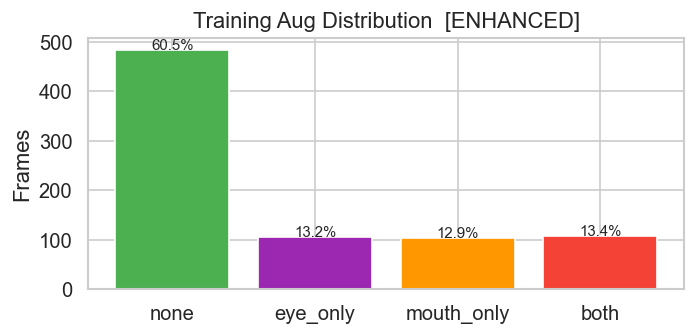

In [38]:
# Show augmentation distribution in the training set
aug_counts = Counter(s['aug_type'] for s in train_samples)
total = len(train_samples)
print('Training augmentation distribution:')
for t in ['none', 'eye_only', 'mouth_only', 'both']:
    n = aug_counts.get(t, 0)
    print(f'  {t:<12}: {n:5d}  ({n/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 3))
labels  = [t for t in ['none', 'eye_only', 'mouth_only', 'both'] if aug_counts.get(t, 0)]
values  = [aug_counts[t] for t in labels]
colors  = ['#4CAF50', '#9C27B0', '#FF9800', '#F44336']
ax.bar(labels, values, color=colors[:len(labels)])
ax.set(ylabel='Frames', title=f'Training Aug Distribution  [{MODEL_TYPE.upper()}]')
for rect, v in zip(ax.patches, values):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.5,
            f'{v/total*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'exp_aplus_{MODEL_TYPE}_aug_dist.png', bbox_inches='tight')
plt.show()

## 3. DataLoaders

In [39]:
class DriverStateDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        features = {k: torch.tensor(v, dtype=torch.float32) for k, v in s['features'].items()}
        occ = s['occlusion_info'].copy()
        label = torch.tensor(s['label'], dtype=torch.long)
        occ_tgt = torch.tensor([occ['eye_occlusion_prob'], occ['mouth_occlusion_prob']], dtype=torch.float32)
        return {'features': features, 'occlusion_info': occ, 'label': label,
                'occlusion_targets': occ_tgt, 'class_name': s['class_name'],
                'frame_id': s['frame_id'], 'ground_truth': s['ground_truth']}


def collate_fn(batch):
    regions = batch[0]['features'].keys()
    return {
        'features': {r: torch.stack([b['features'][r] for b in batch]) for r in regions},
        'occlusion_info': {
            'eye_occlusion_prob':   torch.tensor([b['occlusion_info']['eye_occlusion_prob']   for b in batch], dtype=torch.float32),
            'mouth_occlusion_prob': torch.tensor([b['occlusion_info']['mouth_occlusion_prob'] for b in batch], dtype=torch.float32),
        },
        'label':           torch.stack([b['label'] for b in batch]),
        'occlusion_targets': torch.stack([b['occlusion_targets'] for b in batch]),
        'class_name':      [b['class_name'] for b in batch],
        'frame_id':        torch.tensor([b['frame_id'] for b in batch]),
        'ground_truth':    [b['ground_truth'] for b in batch],
    }


train_loader = DataLoader(DriverStateDataset(train_samples), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(DriverStateDataset(val_samples),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Batches  Train: {len(train_loader)}  Val: {len(val_loader)}')

Batches  Train: 25  Val: 7


## 4. Initialise & Train

In [40]:
transformer = TransformerCls(
    feature_dim=512, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS,
    num_classes=3, num_layers=NUM_LAYERS, use_relative_pos=True,
).to(device)

print(f'Model: {type(transformer).__name__}  |  Params: {sum(p.numel() for p in transformer.parameters()):,}')

Model: EnhancedOcclusionAwareTransformer  |  Params: 935,878


In [41]:
def move_batch(batch, dev):
    def to_dev(x):
        if isinstance(x, torch.Tensor):
            return x.float().to(dev) if x.is_floating_point() else x.to(dev)
        if isinstance(x, dict):
            return {k: to_dev(v) for k, v in x.items()}
        if isinstance(x, (float, int)):
            return torch.tensor(x, dtype=torch.float32, device=dev)
        return x
    return {k: to_dev(v) if k not in ('class_name', 'ground_truth') else v for k, v in batch.items()}


optimizer = torch.optim.AdamW(transformer.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    transformer.train()
    losses, correct, total = [], 0, 0
    for batch in train_loader:
        batch = move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        out = transformer(batch['features'], batch['occlusion_info'])
        loss = criterion(out['class_logits'], batch['label'])
        # Gate alignment loss: directly teach gate MLPs to suppress when p_occ is high
        # gate_factors shape: (B, 4) -> [face, left_eye, right_eye, mouth]
        # occlusion_targets shape: (B, 2) -> [eye_prob, mouth_prob]
        occ_tgt = batch['occlusion_targets']
        eye_target   = 0.3 + 0.7 * (1.0 - occ_tgt[:, 0].clamp(0, 1))
        mouth_target = 0.3 + 0.7 * (1.0 - occ_tgt[:, 1].clamp(0, 1))
        gf = out['gate_factors']
        gate_occ_reg = (F.mse_loss(gf[:, 1], eye_target) +
                        F.mse_loss(gf[:, 2], eye_target) +
                        F.mse_loss(gf[:, 3], mouth_target))
        # Diversity regularisation: encourage gate values to vary across regions
        gate_div_reg = -0.01 * torch.var(out['gate_factors'], dim=1).mean()
        loss = loss + 0.1 * gate_occ_reg + gate_div_reg
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        correct += (out['predicted_class'].view(-1) == batch['label'].view(-1)).sum().item()
        total   += batch['label'].size(0)
    scheduler.step()
    t_loss, t_acc = np.mean(losses), correct / max(total, 1) * 100

    transformer.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = move_batch(batch, device)
            o = transformer(batch['features'], batch['occlusion_info'])
            vc += (o['predicted_class'].view(-1) == batch['label'].view(-1)).sum().item()
            vt += batch['label'].size(0)
    v_acc = vc / max(vt, 1) * 100

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    tag = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        ckpt = f'exp_aplus_{MODEL_TYPE}_best.pt'
        torch.save(transformer, ckpt)
        tag = f'  ** saved'

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f'Ep {epoch+1:3d}/{NUM_EPOCHS}: loss={t_loss:.4f}  train={t_acc:.1f}%  val={v_acc:.1f}%{tag}')

print(f'\nBest val: {best_val_acc:.1f}%')

Ep   1/20: loss=0.8696  train=72.0%  val=78.0%  ** saved
Ep   2/20: loss=0.7657  train=75.1%  val=78.0%
Ep   4/20: loss=0.5887  train=78.9%  val=85.5%  ** saved
Ep   6/20: loss=0.4841  train=83.2%  val=90.0%  ** saved
Ep   8/20: loss=0.3862  train=87.1%  val=88.0%
Ep  10/20: loss=0.3533  train=88.2%  val=92.5%  ** saved
Ep  12/20: loss=0.3321  train=88.9%  val=93.5%  ** saved
Ep  14/20: loss=0.3263  train=89.1%  val=93.5%
Ep  16/20: loss=0.2868  train=91.4%  val=93.0%
Ep  18/20: loss=0.3017  train=90.1%  val=93.0%
Ep  20/20: loss=0.2920  train=91.9%  val=93.0%

Best val: 93.5%


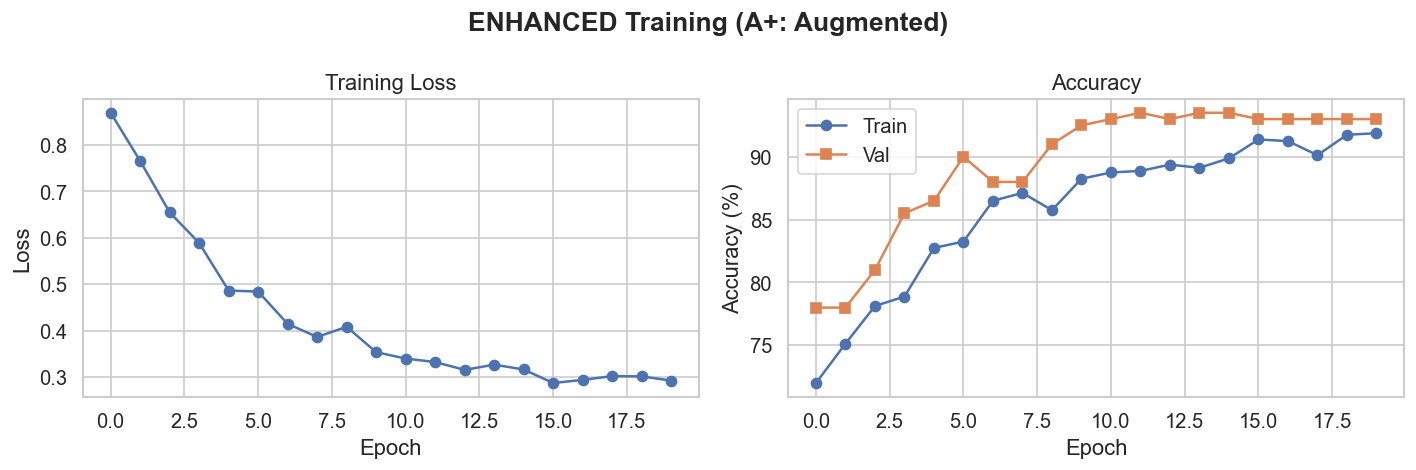

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], 'o-'); ax1.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax2.plot(history['train_acc'], 'o-', label='Train'); ax2.plot(history['val_acc'], 's-', label='Val')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Accuracy'); ax2.legend()
fig.suptitle(f'{MODEL_TYPE.upper()} Training (A+: Augmented)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'exp_aplus_{MODEL_TYPE}_training.png', bbox_inches='tight'); plt.show()

In [43]:
# Load best checkpoint for stress-testing
ckpt = f'exp_aplus_{MODEL_TYPE}_best.pt'
transformer = torch.load(ckpt, map_location=device, weights_only=False)
transformer.to(device); transformer.eval()
print(f'Loaded {ckpt}')
print('Clean test accuracy will be computed from the stress-test "none" condition below.')

Loaded exp_aplus_enhanced_best.pt
Clean test accuracy will be computed from the stress-test "none" condition below.


## 5. Gating Helper

In [44]:
def run_with_gating_disabled(model, features, occlusion_info):
    if hasattr(model, 'compute_dynamic_gates'):
        orig = model.compute_dynamic_gates
        def _off(rf, oi, bs, dev):
            return torch.ones(bs, 4, device=dev), {
                'content':[], 'cross_region':[], 'occlusion_refined':[],
                'bounds':(1.,1.), 'temperature':1.}
        model.compute_dynamic_gates = _off
        try:
            return model(features, occlusion_info, return_attention=True)
        finally:
            model.compute_dynamic_gates = orig
    else:
        return model(features, occlusion_info, return_attention=True, disable_gating=True)

_df = {r: torch.randn(1,512).to(device) for r in ['face','left_eye','right_eye','mouth']}
_oi = {'eye_occlusion_prob': .5, 'mouth_occlusion_prob': .5}
with torch.no_grad():
    g_on  = transformer(_df, _oi)['gate_factors'].squeeze().cpu().numpy()
    g_off = run_with_gating_disabled(transformer, _df, _oi)['gate_factors'].squeeze().cpu().numpy()
print(f'ON  gates: {g_on.round(3)}')
print(f'OFF gates: {g_off.round(3)}')
del _df, _oi

ON  gates: [1.    0.655 0.655 0.654]
OFF gates: [1. 1. 1. 1.]


## 6. Stress Test: Synthetic Occlusion on Test Subjects

Identical protocol to Experiment A:
- 4 occlusion types × 5 opacity levels + clean baseline = **16 conditions per frame**
- Both Gating ON and Gating OFF evaluated for every condition

In [45]:
test_csv = {k: v for k, v in csv_data.items() if k in splits['test']}
sampled = sample_frames_for_audit(
    test_csv, max_per_subject=MAX_PER_SUBJECT, include_all_occluded=True, seed=42,
)
total_frames = sum(len(v) for v in sampled.values())
print(f'Stress-test: {total_frames} frames from {len(sampled)} videos')

  Sub1_sub1_video: 30 occluded + 0 non-occluded = 30 frames
  Sub2_sub2_video: 1 occluded + 29 non-occluded = 30 frames
  Sub3_sub3_video: 1 occluded + 29 non-occluded = 30 frames
  Sub8_sub8_video: 2 occluded + 28 non-occluded = 30 frames
  Sub9_sub9_video: 1 occluded + 29 non-occluded = 30 frames
Stress-test: 150 frames from 5 videos


In [46]:
LABEL_MAP = CONFIG['CSV_LABELS']
occlusion_configs = [
    ('none',       0.0, 0.0),
    ('eye_only',   1.0, 0.0),
    ('mouth_only', 0.0, 1.0),
    ('both',       1.0, 1.0),
]
opacity_levels = OPACITY_LEVELS

# GPU warm-up: run ~10 dummy passes so CUDA kernels are compiled and
# memory is allocated before timing starts. Without this, the first
# 1-3 frames are 5-20x slower due to JIT compilation.
use_cuda = (device.type == 'cuda')
print('Warming up GPU...') if use_cuda else print('CPU mode – skipping GPU warm-up')
_w_feat = {r: torch.randn(1, 512, device=device) for r in ['face','left_eye','right_eye','mouth']}
_w_occ  = {'eye_occlusion_prob': 0.0, 'mouth_occlusion_prob': 0.0}
for _ in range(10):
    with torch.no_grad():
        _ = transformer(_w_feat, _w_occ)
if use_cuda: torch.cuda.synchronize()
del _w_feat, _w_occ
print('Warm-up done.\n')

rows = []
total = sum(len(v) for v in sampled.values())
processed, skipped = 0, 0
t0 = time.time()

for video_key, ann_list in sampled.items():
    meta = csv_data[video_key]
    cap = cv2.VideoCapture(meta['video_path'])
    if not cap.isOpened(): continue
    subject = meta['subject']
    print(f'  {video_key} ({len(ann_list)} frames) ...')

    for ann in ann_list:
        cap.set(cv2.CAP_PROP_POS_FRAMES, ann.frame)
        ret, bgr = cap.read()
        if not ret: continue

        # Phase 1: face detection + landmark extraction (once per raw frame)
        _t = time.perf_counter()
        det = face_detector.detect_face_and_landmarks(bgr)
        t_det = (time.perf_counter() - _t) * 1000

        if not det['is_valid']: skipped += 1; processed += 1; continue
        lm, fb, er, mr = det['landmarks'], det['face_bbox'], det['eye_regions'], det['mouth_region']
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        if ann.class_label not in LABEL_MAP: processed += 1; continue
        gt = LABEL_MAP[ann.class_label]

        for opacity in opacity_levels:
            for occ_name, eflag, mflag in occlusion_configs:
                if occ_name == 'none' and opacity > 0: continue
                if occ_name != 'none' and opacity == 0: continue
                eo = opacity if eflag else 0.0
                mo = opacity if mflag else 0.0

                aug_rgb = apply_synthetic_occlusion(rgb, lm, eye_opacity=eo, mouth_opacity=mo) if occ_name != 'none' else rgb
                aug_bgr = cv2.cvtColor(aug_rgb, cv2.COLOR_RGB2BGR) if occ_name != 'none' else bgr

                # Phase 2: feature extraction (ResNet34 backbone, GPU)
                if use_cuda: torch.cuda.synchronize()
                _t = time.perf_counter()
                feat = feat_extractor.extract_region_features(aug_bgr, fb, er, mr)
                if use_cuda: torch.cuda.synchronize()
                t_feat = (time.perf_counter() - _t) * 1000

                rkeys = ['face_features','left_eye_features','right_eye_features','mouth_features']
                if any(feat[k] is None for k in rkeys): continue
                fdict = {'face': feat['face_features'], 'left_eye': feat['left_eye_features'],
                         'right_eye': feat['right_eye_features'], 'mouth': feat['mouth_features']}

                # Phase 3: occlusion estimator (ONNX, CPU-bound)
                _t = time.perf_counter()
                probs = occ_model.predict_probs(aug_rgb, face_bbox=fb, image_bgr=False, face_margin=0.15)
                t_occ = (time.perf_counter() - _t) * 1000
                occ_info = {'eye_occlusion_prob': float(probs[0]), 'mouth_occlusion_prob': float(probs[1])}

                # Phase 4: transformer (GPU)
                if use_cuda: torch.cuda.synchronize()
                _t = time.perf_counter()
                with torch.no_grad():
                    out_on  = transformer(fdict, occ_info, return_attention=True)
                    out_off = run_with_gating_disabled(transformer, fdict, occ_info)
                if use_cuda: torch.cuda.synchronize()
                t_trans = (time.perf_counter() - _t) * 1000

                gates = out_on['gate_factors'].squeeze().cpu().numpy()

                rows.append({
                    'subject': subject, 'frame': ann.frame,
                    'class_label': ann.class_label, 'gt_label': gt,
                    'occlusion_type': occ_name,
                    'opacity': opacity if occ_name != 'none' else 0.0,
                    'p_eye': float(probs[0]), 'p_mouth': float(probs[1]),
                    'pred_gating_on':  int(out_on['predicted_class'].item()),
                    'pred_gating_off': int(out_off['predicted_class'].item()),
                    'correct_gating_on':  int(out_on['predicted_class'].item() == gt),
                    'correct_gating_off': int(out_off['predicted_class'].item() == gt),
                    'gate_face': float(gates[0]), 'gate_eye': float(gates[1]), 'gate_mouth': float(gates[3]),
                    't_det_ms':   round(t_det,  3),
                    't_feat_ms':  round(t_feat, 3),
                    't_occ_ms':   round(t_occ,  3),
                    't_trans_ms': round(t_trans, 3),
                    't_total_ms': round(t_det + t_feat + t_occ + t_trans, 3),
                })

        processed += 1
        if processed % 25 == 0:
            print(f'    [{processed}/{total}] {processed/(time.time()-t0):.1f} fr/s')
    cap.release()

print(f'\nDone: {processed} frames, {skipped} skipped, {time.time()-t0:.0f}s')
df = pd.DataFrame(rows)
df.to_csv(f'experiment_aplus_{MODEL_TYPE}_results.csv', index=False)
print(f'Saved {len(df)} rows')

# Latency summary — use 'none' condition rows as proxy for single-pass real-world latency
lat = df[df['occlusion_type'] == 'none']
print(f'\nLatency summary (ms) over {len(lat)} clean-pass frames:')
print(f'  {"Phase":<22}  {"mean":>7}  {"median":>7}  {"p95":>7}')
print(f'  {"-"*50}')
for col, label in [
    ('t_det_ms',   'Face detect + lm'),
    ('t_feat_ms',  'Feature extraction'),
    ('t_occ_ms',   'Occlusion estimator'),
    ('t_trans_ms', 'Transformer'),
    ('t_total_ms', 'TOTAL'),
]:
    print(f'  {label:<22}  {lat[col].mean():>7.2f}  {lat[col].median():>7.2f}  {lat[col].quantile(.95):>7.2f}')

# Save latency summary to CSV
lat_summary = pd.DataFrame([
    {
        'phase': label,
        'mean_ms':   round(lat[col].mean(), 3),
        'median_ms': round(lat[col].median(), 3),
        'p95_ms':    round(lat[col].quantile(.95), 3),
        'std_ms':    round(lat[col].std(), 3),
    }
    for col, label in [
        ('t_det_ms',   'Face detect + lm'),
        ('t_feat_ms',  'Feature extraction'),
        ('t_occ_ms',   'Occlusion estimator'),
        ('t_trans_ms', 'Transformer'),
        ('t_total_ms', 'TOTAL'),
    ]
])
lat_summary.to_csv(f'experiment_aplus_{MODEL_TYPE}_latency.csv', index=False)
print(lat_summary.to_string(index=False))

df.head()

CPU mode – skipping GPU warm-up
Warm-up done.

  Sub1_sub1_video (30 frames) ...
    [25/150] 0.5 fr/s
  Sub2_sub2_video (30 frames) ...
    [50/150] 0.5 fr/s
  Sub3_sub3_video (30 frames) ...
    [75/150] 0.5 fr/s
  Sub8_sub8_video (30 frames) ...
    [100/150] 0.5 fr/s
  Sub9_sub9_video (30 frames) ...
    [125/150] 0.5 fr/s
    [150/150] 0.5 fr/s

Done: 150 frames, 0 skipped, 292s
Saved 2400 rows

Latency summary (ms) over 150 clean-pass frames:
  Phase                      mean   median      p95
  --------------------------------------------------
  Face detect + lm          33.49    31.59    35.83
  Feature extraction        84.45    83.13    89.72
  Occlusion estimator       21.31    20.91    23.57
  Transformer                1.21     1.16     1.39
  TOTAL                    140.46   136.88   149.69
              phase  mean_ms  median_ms  p95_ms  std_ms
   Face detect + lm   33.488     31.586  35.831  11.874
 Feature extraction   84.453     83.128  89.720   5.431
Occlusion esti

,subject,frame,class_label,gt_label,occlusion_type,opacity,p_eye,p_mouth,pred_gating_on,pred_gating_off,correct_gating_on,correct_gating_off,gate_face,gate_eye,gate_mouth,t_det_ms,t_feat_ms,t_occ_ms,t_trans_ms,t_total_ms
0,Sub1,117,Neutral,2,none,0.0,0.000399,0.000170,2,2,1,1,1.0,0.652683,0.653258,140.602,133.995,33.453,1.579,309.630
1,Sub1,117,Neutral,2,eye_only,0.3,0.046049,0.000677,2,2,1,1,1.0,0.652986,0.653291,140.602,81.812,21.480,1.234,245.128
2,Sub1,117,Neutral,2,mouth_only,0.3,0.000641,0.000684,2,2,1,1,1.0,0.652692,0.653291,140.602,91.453,22.608,1.241,255.904
3,Sub1,117,Neutral,2,both,0.3,0.061869,0.002470,2,2,1,1,1.0,0.653019,0.653408,140.602,86.387,21.310,1.220,249.519
4,Sub1,117,Neutral,2,eye_only,0.5,0.938979,0.000475,2,2,1,1,1.0,0.656529,0.653278,140.602,85.141,21.400,1.256,248.399


## 7. Analysis & Visualisation

In [47]:
CN = {0: 'EyeClosed', 1: 'Yawn', 2: 'Neutral'}
summary_rows = []

b  = df[df['occlusion_type'] == 'none']
bl_on, bl_off = b['correct_gating_on'].mean()*100, b['correct_gating_off'].mean()*100
print(f'BASELINE (no occlusion): ON={bl_on:.1f}%  OFF={bl_off:.1f}%  n={len(b)}')
summary_rows.append({'occ_type':'none','opacity':0,'acc_on':bl_on,'acc_off':bl_off,
                     'delta':bl_on-bl_off,'n':len(b)})

for ot in ['eye_only', 'mouth_only', 'both']:
    sub = df[df['occlusion_type'] == ot]
    print(f'\n{ot.upper()}:')
    for op in sorted(sub['opacity'].unique()):
        ss = sub[sub['opacity'] == op]
        a_on, a_off = ss['correct_gating_on'].mean()*100, ss['correct_gating_off'].mean()*100
        d = a_on - a_off
        m = ' ***' if d > 2 else (' *' if d > .5 else '')
        print(f'  opacity={op:.1f}  ON={a_on:.1f}%  OFF={a_off:.1f}%  delta={d:+.1f}pp{m}  n={len(ss)}')
        summary_rows.append({'occ_type':ot,'opacity':op,'acc_on':a_on,'acc_off':a_off,'delta':d,'n':len(ss)})

df_summary = pd.DataFrame(summary_rows)
df_summary

BASELINE (no occlusion): ON=87.3%  OFF=86.0%  n=150

EYE_ONLY:
  opacity=0.3  ON=85.3%  OFF=83.3%  delta=+2.0pp *  n=150
  opacity=0.5  ON=86.0%  OFF=84.7%  delta=+1.3pp *  n=150
  opacity=0.7  ON=87.3%  OFF=84.0%  delta=+3.3pp ***  n=150
  opacity=0.9  ON=80.7%  OFF=80.7%  delta=+0.0pp  n=150
  opacity=1.0  ON=81.3%  OFF=82.0%  delta=-0.7pp  n=150

MOUTH_ONLY:
  opacity=0.3  ON=89.3%  OFF=88.0%  delta=+1.3pp *  n=150
  opacity=0.5  ON=89.3%  OFF=87.3%  delta=+2.0pp *  n=150
  opacity=0.7  ON=90.0%  OFF=90.7%  delta=-0.7pp  n=150
  opacity=0.9  ON=88.0%  OFF=86.0%  delta=+2.0pp *  n=150
  opacity=1.0  ON=83.3%  OFF=83.3%  delta=+0.0pp  n=150

BOTH:
  opacity=0.3  ON=84.0%  OFF=81.3%  delta=+2.7pp ***  n=150
  opacity=0.5  ON=88.0%  OFF=86.7%  delta=+1.3pp *  n=150
  opacity=0.7  ON=88.0%  OFF=86.7%  delta=+1.3pp *  n=150
  opacity=0.9  ON=79.3%  OFF=81.3%  delta=-2.0pp  n=150
  opacity=1.0  ON=76.0%  OFF=76.7%  delta=-0.7pp  n=150


,occ_type,opacity,acc_on,acc_off,delta,n
0,none,0.0,87.333333,86.000000,1.333333,150
1,eye_only,0.3,85.333333,83.333333,2.000000,150
2,eye_only,0.5,86.000000,84.666667,1.333333,150
3,eye_only,0.7,87.333333,84.000000,3.333333,150
4,eye_only,0.9,80.666667,80.666667,0.000000,150
5,eye_only,1.0,81.333333,82.000000,-0.666667,150
6,mouth_only,0.3,89.333333,88.000000,1.333333,150
7,mouth_only,0.5,89.333333,87.333333,2.000000,150
8,mouth_only,0.7,90.000000,90.666667,-0.666667,150
9,mouth_only,0.9,88.000000,86.000000,2.000000,150


In [48]:
print(f'\nPER-CLASS at high opacity (>=0.9)  [{MODEL_TYPE.upper()} A+]')
for ot in ['eye_only','mouth_only','both']:
    sub = df[(df['occlusion_type']==ot) & (df['opacity']>=0.9)]
    print(f'  {ot.upper()} (n={len(sub)}):')
    for cid, cn in CN.items():
        cs = sub[sub['gt_label']==cid]
        if len(cs) == 0: continue
        a_on  = cs['correct_gating_on'].mean()*100
        a_off = cs['correct_gating_off'].mean()*100
        print(f'    {cn:<12}: ON={a_on:.1f}%  OFF={a_off:.1f}%  d={a_on-a_off:+.1f}pp (n={len(cs)})')


PER-CLASS at high opacity (>=0.9)  [ENHANCED A+]
  EYE_ONLY (n=300):
    EyeClosed   : ON=5.3%  OFF=0.0%  d=+5.3pp (n=38)
    Yawn        : ON=34.4%  OFF=43.8%  d=-9.4pp (n=32)
    Neutral     : ON=100.0%  OFF=100.0%  d=+0.0pp (n=230)
  MOUTH_ONLY (n=300):
    EyeClosed   : ON=65.8%  OFF=55.3%  d=+10.5pp (n=38)
    Yawn        : ON=15.6%  OFF=18.8%  d=-3.1pp (n=32)
    Neutral     : ON=98.7%  OFF=98.7%  d=+0.0pp (n=230)
  BOTH (n=300):
    EyeClosed   : ON=7.9%  OFF=5.3%  d=+2.6pp (n=38)
    Yawn        : ON=9.4%  OFF=15.6%  d=-6.2pp (n=32)
    Neutral     : ON=98.7%  OFF=100.0%  d=-1.3pp (n=230)


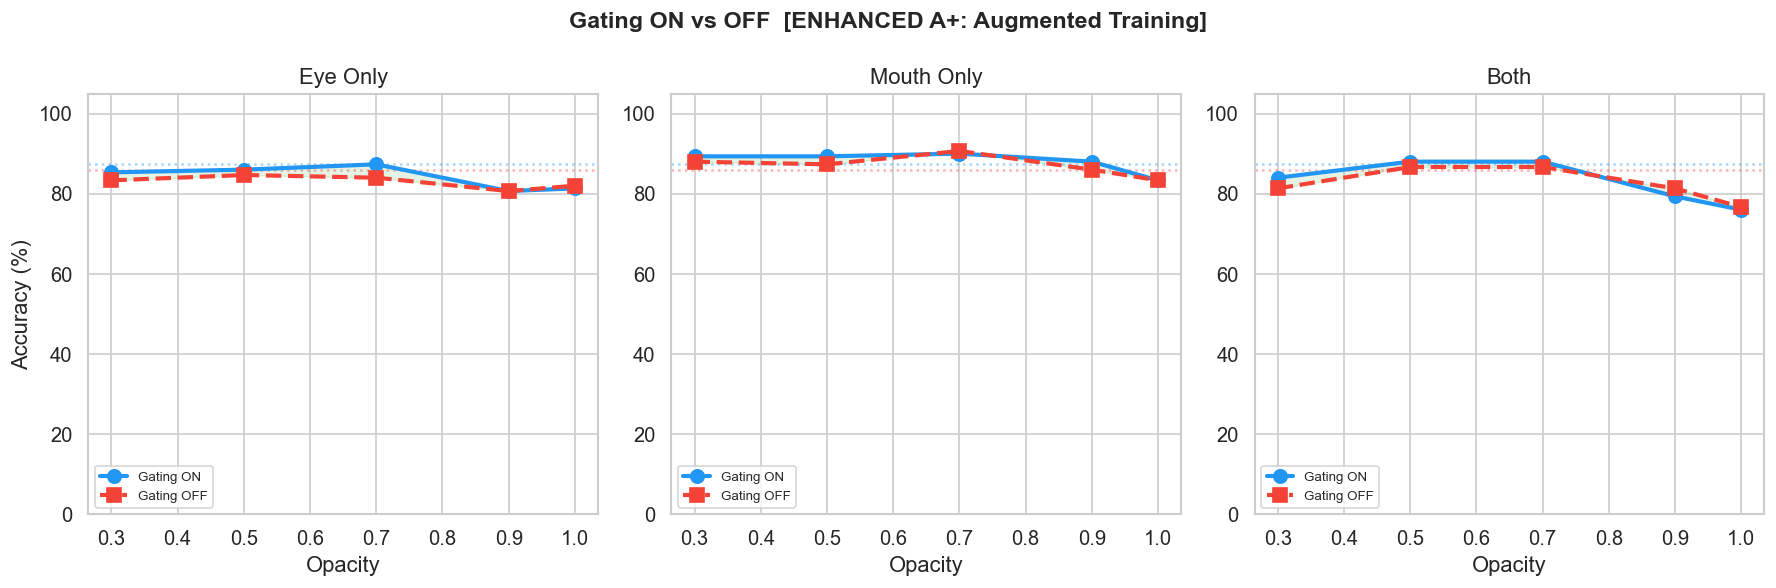

In [49]:
bl = df_summary[df_summary['occ_type']=='none']
bl_on, bl_off = (bl['acc_on'].values[0], bl['acc_off'].values[0]) if len(bl) else (0,0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ot in zip(axes, ['eye_only','mouth_only','both']):
    s = df_summary[df_summary['occ_type']==ot]
    ax.plot(s['opacity'], s['acc_on'],  'o-', color='#2196F3', lw=2.5, ms=8, label='Gating ON',  zorder=3)
    ax.plot(s['opacity'], s['acc_off'], 's--', color='#F44336', lw=2.5, ms=8, label='Gating OFF', zorder=3)
    ax.axhline(bl_on,  color='#2196F3', ls=':', alpha=.4)
    ax.axhline(bl_off, color='#F44336', ls=':', alpha=.4)
    ax.fill_between(s['opacity'], s['acc_off'], s['acc_on'], alpha=.15, color='#4CAF50')
    ax.set(xlabel='Opacity', title=ot.replace('_',' ').title(), ylim=(0,105))
    ax.legend(fontsize=8, loc='lower left')
axes[0].set_ylabel('Accuracy (%)')
fig.suptitle(f'Gating ON vs OFF  [{MODEL_TYPE.upper()} A+: Augmented Training]', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'exp_aplus_{MODEL_TYPE}_accuracy.png', bbox_inches='tight')
plt.show()

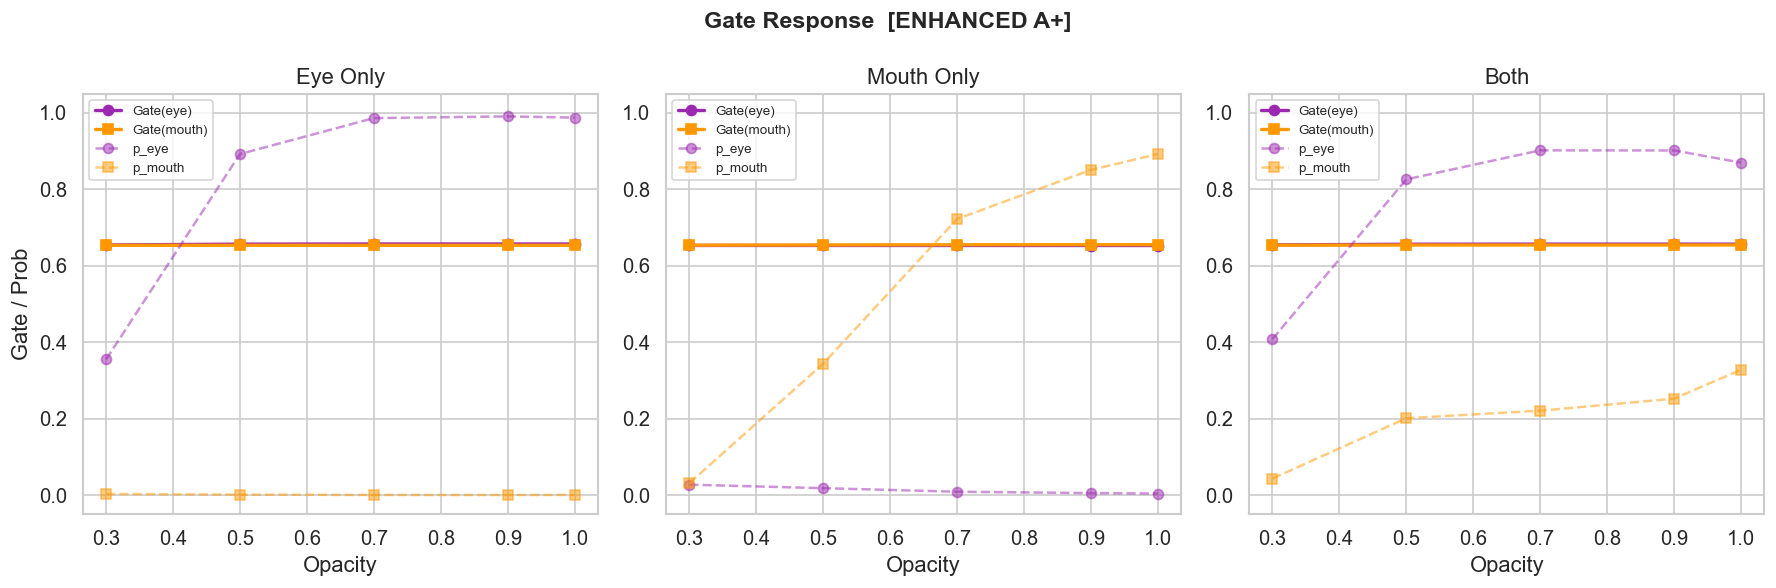

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ot in zip(axes, ['eye_only','mouth_only','both']):
    s = df[df['occlusion_type']==ot].groupby('opacity').agg(
        gate_eye=('gate_eye','mean'), gate_mouth=('gate_mouth','mean'),
        p_eye=('p_eye','mean'), p_mouth=('p_mouth','mean')).reset_index()
    ax.plot(s['opacity'], s['gate_eye'],   'o-',  color='#9C27B0', lw=2,   label='Gate(eye)')
    ax.plot(s['opacity'], s['gate_mouth'], 's-',  color='#FF9800', lw=2,   label='Gate(mouth)')
    ax.plot(s['opacity'], s['p_eye'],      'o--', color='#9C27B0', alpha=.5, lw=1.5, label='p_eye')
    ax.plot(s['opacity'], s['p_mouth'],    's--', color='#FF9800', alpha=.5, lw=1.5, label='p_mouth')
    ax.set(xlabel='Opacity', title=ot.replace('_',' ').title(), ylim=(-.05,1.05))
    ax.legend(fontsize=8)
axes[0].set_ylabel('Gate / Prob')
fig.suptitle(f'Gate Response  [{MODEL_TYPE.upper()} A+]', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'exp_aplus_{MODEL_TYPE}_gates.png', bbox_inches='tight')
plt.show()

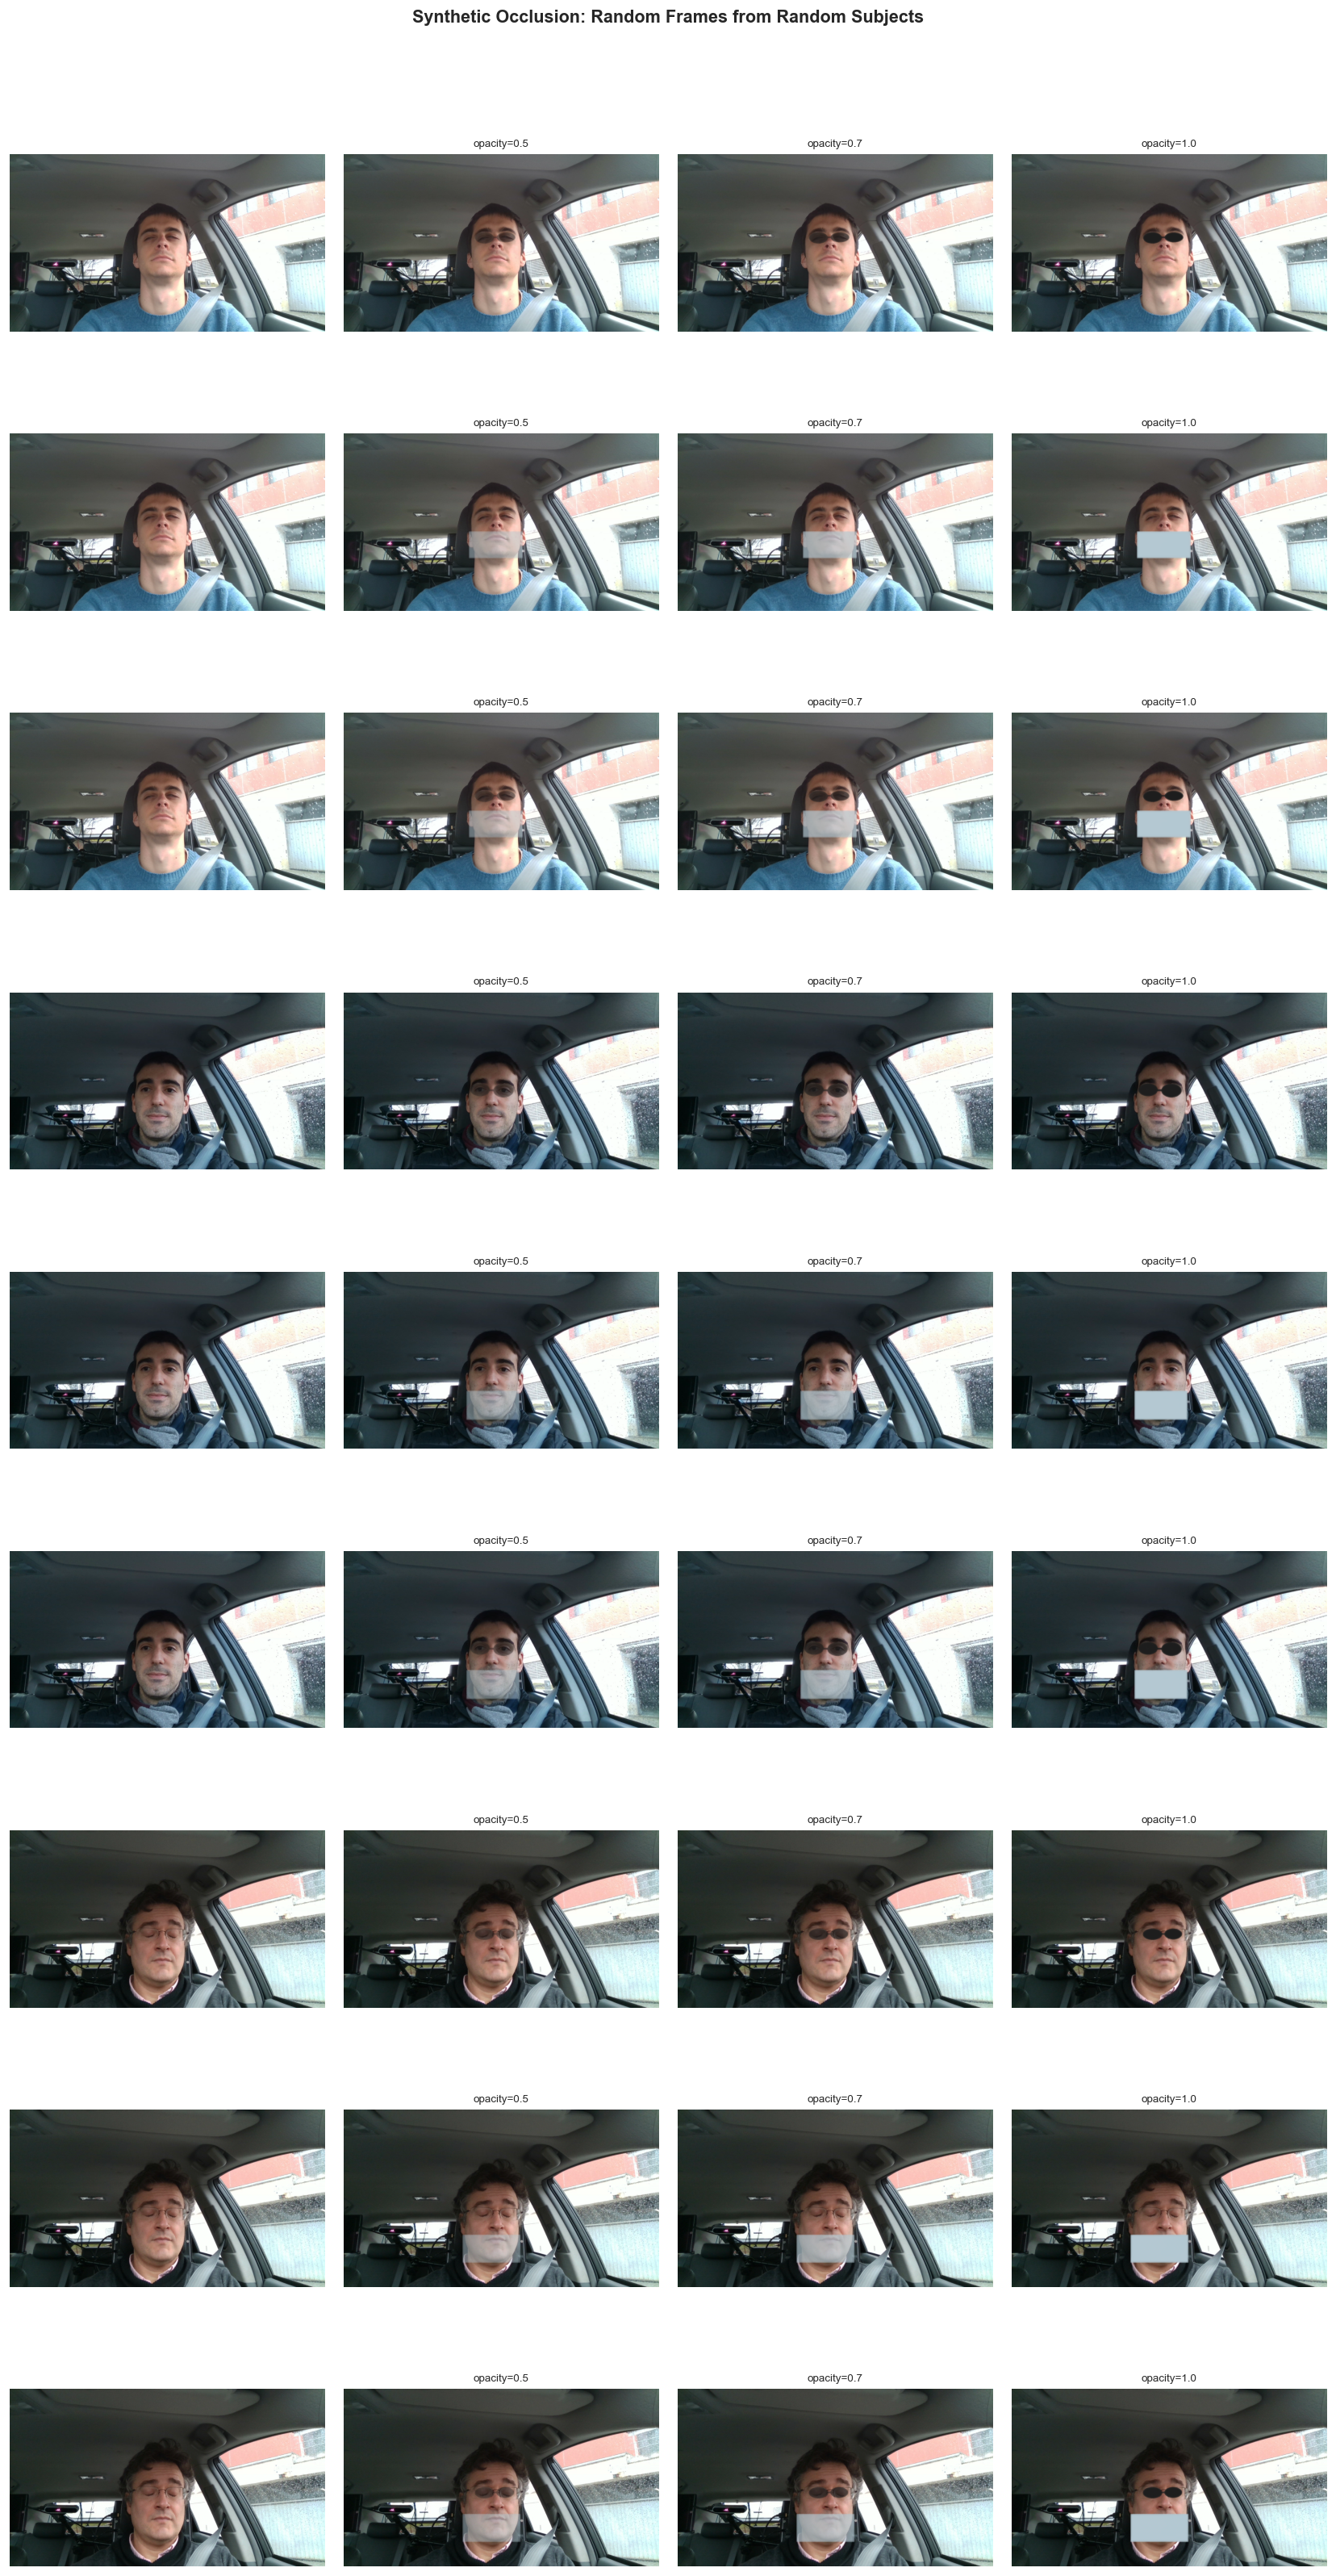

In [51]:
# Synthetic occlusion examples (one random frame from each test subject)
import random as _rnd

n_subjects   = min(3, len(sampled))
n_opacities  = 4
vis_opacities = [0.0, 0.5, 0.7, 1.0]
occ_types = [
    ('Eye',   lambda o: o, lambda o: 0.0),
    ('Mouth', lambda o: 0.0, lambda o: o),
    ('Both',  lambda o: o, lambda o: o),
]

subj_keys = _rnd.sample(list(sampled.keys()), n_subjects)
n_rows = n_subjects * len(occ_types)
fig, axes = plt.subplots(n_rows, n_opacities, figsize=(3.5 * n_opacities, 3 * n_rows))
if n_rows == 1: axes = axes[np.newaxis, :]

row = 0
for sk in subj_keys:
    ann = _rnd.choice(sampled[sk])
    video_path = csv_data[sk]['video_path']
    cap_vis = cv2.VideoCapture(video_path)
    cap_vis.set(cv2.CAP_PROP_POS_FRAMES, ann.frame)
    ret, bgr_v = cap_vis.read(); cap_vis.release()
    if not ret: row += len(occ_types); continue
    det_v = face_detector.detect_face_and_landmarks(bgr_v)
    if not det_v['is_valid']: row += len(occ_types); continue
    vr = cv2.cvtColor(bgr_v, cv2.COLOR_BGR2RGB)
    vl = det_v.get('landmarks')
    subj_label = csv_data[sk]['subject']

    for occ_label, eye_fn, mouth_fn in occ_types:
        for c, op in enumerate(vis_opacities):
            if op == 0:
                img = vr
            else:
                img = apply_synthetic_occlusion(vr, vl, eye_opacity=eye_fn(op), mouth_opacity=mouth_fn(op))
            axes[row, c].imshow(img); axes[row, c].axis('off')
            if c == 0:
                axes[row, c].set_ylabel(f'{subj_label}\n{occ_label}', fontsize=8)
            else:
                axes[row, c].set_title(f'opacity={op:.1f}', fontsize=8)
        row += 1

fig.suptitle('Synthetic Occlusion: Random Frames from Random Subjects',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'exp_aplus_{MODEL_TYPE}_random_subjects_visual.png', bbox_inches='tight')
plt.show()

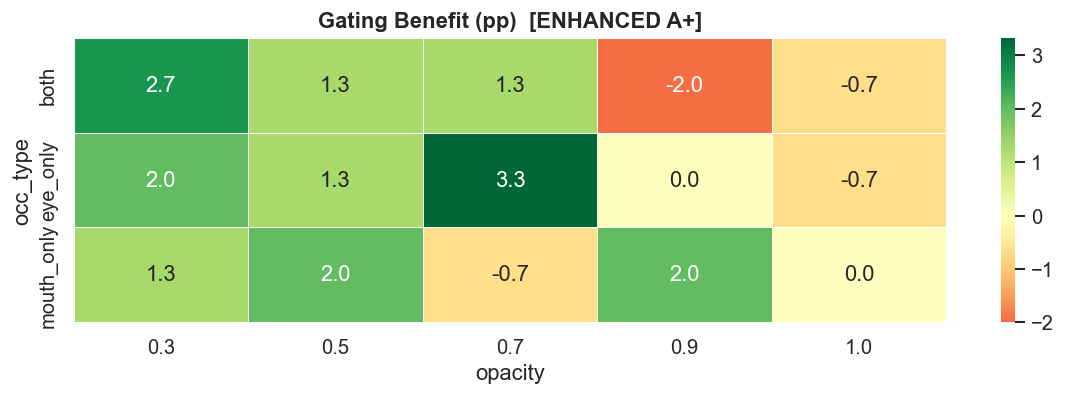

In [52]:
pivot = df_summary[df_summary['occ_type']!='none'].pivot(index='occ_type', columns='opacity', values='delta')
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=.5, ax=ax)
ax.set_title(f'Gating Benefit (pp)  [{MODEL_TYPE.upper()} A+]', fontweight='bold')
plt.tight_layout()
plt.savefig(f'exp_aplus_{MODEL_TYPE}_heatmap.png', bbox_inches='tight')
plt.show()

In [53]:
b  = df[df['occlusion_type'] == 'none']
h  = df[(df['opacity'] >= 0.7) & (df['occlusion_type'] != 'none')]
mx = df_summary[df_summary['occ_type'] != 'none'].loc[df_summary[df_summary['occ_type'] != 'none']['delta'].idxmax()]

b_on,  b_off  = b['correct_gating_on'].mean()*100, b['correct_gating_off'].mean()*100
h_on,  h_off  = h['correct_gating_on'].mean()*100, h['correct_gating_off'].mean()*100
n_frames   = df['frame'].nunique()
n_subjects = df['subject'].nunique()

print('=' * 70)
print(f'EXPERIMENT A+ SUMMARY  [{MODEL_TYPE.upper()}]  (Augmented Training)')
print('=' * 70)

print(f'\n--- Clean Test Accuracy (no synthetic occlusion) ---')
print(f'  Gating ON  : {b_on:.1f}%')
print(f'  Gating OFF : {b_off:.1f}%')
print(f'  Benefit    : {b_on - b_off:+.1f}pp')
print(f'  (evaluated on {len(b)} frames from {n_subjects} test subjects)')

print(f'\n--- Under Heavy Occlusion (opacity >= 0.7) ---')
print(f'  Gating ON  : {h_on:.1f}%')
print(f'  Gating OFF : {h_off:.1f}%')
print(f'  Benefit    : {h_on - h_off:+.1f}pp')

print(f'\n--- Accuracy Drop from Clean Baseline ---')
print(f'  Gating ON  : {b_on:.1f}% -> {h_on:.1f}%  ({h_on - b_on:+.1f}pp)')
print(f'  Gating OFF : {b_off:.1f}% -> {h_off:.1f}%  ({h_off - b_off:+.1f}pp)')

print(f'\n--- Max Gating Benefit ---')
print(f'Max gating benefit: {mx["occ_type"]} at opacity={mx["opacity"]:.1f} -> {mx["delta"]:+.1f}pp')
print(f'Total: {len(df)} rows | {n_frames} unique frames | {n_subjects} test subjects')

EXPERIMENT A+ SUMMARY  [ENHANCED]  (Augmented Training)

--- Clean Test Accuracy (no synthetic occlusion) ---
  Gating ON  : 87.3%
  Gating OFF : 86.0%
  Benefit    : +1.3pp
  (evaluated on 150 frames from 5 test subjects)

--- Under Heavy Occlusion (opacity >= 0.7) ---
  Gating ON  : 83.8%
  Gating OFF : 83.5%
  Benefit    : +0.3pp

--- Accuracy Drop from Clean Baseline ---
  Gating ON  : 87.3% -> 83.8%  (-3.6pp)
  Gating OFF : 86.0% -> 83.5%  (-2.5pp)

--- Max Gating Benefit ---
Max gating benefit: eye_only at opacity=0.7 -> +3.3pp
Total: 2400 rows | 150 unique frames | 5 test subjects
